In [2]:
import pandas as pd
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import semopy
import rpy2

In [3]:
pd.set_option("display.max_columns", None)
# pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", "{:.0f}".format)

# Loading the data

In [4]:
raw_responses = pd.read_parquet("../data/survey/survey_cleaned.parquet") # survey responses only
main_block = pd.read_parquet("../data/analysis/individual/main_block_individual.parquet").reset_index(drop=True) # survey merged with operational kpis

In [5]:
raw_responses['metadata_departure_date'] = pd.to_datetime(
    raw_responses['metadata_departure_date'], errors='coerce'
)

print(f"Total number of observations, raw responses vs. filtered responses for analysis: {len(raw_responses)} -> {len(main_block)}\n")
print(f"Date range, raw responses vs. filtered responses for analysis:")
print(f"Raw responses: {raw_responses['metadata_departure_date'].min()} - {raw_responses['metadata_departure_date'].max()}")
print(f"Filtered responses: {main_block['origin_theoretical_time'].min()} - {main_block['origin_theoretical_time'].max()}")

print(f"Total number of observations, raw responses vs. filtered responses for analysis: {len(raw_responses)} -> {len(main_block)}\n")
print(f"Date range, raw responses vs. filtered responses for analysis:")
print(f"Raw responses: {raw_responses['metadata_departure_date'].min()} - {raw_responses['metadata_departure_date'].max()}")
print(f"Filtered responses: {main_block['origin_theoretical_time'].min()} - {main_block['origin_theoretical_time'].max()}")

Total number of observations, raw responses vs. filtered responses for analysis: 276151 -> 112808

Date range, raw responses vs. filtered responses for analysis:
Raw responses: 2024-04-30 00:00:00+00:00 - 2026-05-13 00:00:00+00:00
Filtered responses: 2025-01-01 11:43:00+00:00 - 2026-05-13 21:19:00+00:00
Total number of observations, raw responses vs. filtered responses for analysis: 276151 -> 112808

Date range, raw responses vs. filtered responses for analysis:
Raw responses: 2024-04-30 00:00:00+00:00 - 2026-05-13 00:00:00+00:00
Filtered responses: 2025-01-01 11:43:00+00:00 - 2026-05-13 21:19:00+00:00


In [6]:
raw_responses.head()

,metadata_booking_date,metadata_class_of_service,metadata_class_of_service_code,metadata_coach_number,metadata_compensation_flag,metadata_currency,metadata_delay_code,metadata_delay_at_arrival,metadata_departure_date,metadata_departure_hour,metadata_destination_station,metadata_destination_station_code,metadata_disrup,metadata_origin_station,metadata_origin_station_code,metadata_price,metadata_on_board_the_train_v,metadata_overall_experience_v,metadata_q14_op,metadata_q17_op,metadata_recommendation_nps_a,metadata_assistance_service_v,metadata_q_total_duration,metadata_route,metadata_route_code,metadata_seat_number,metadata_segment,metadata_segment_code,metadata_tier_level,metadata_tier_level_code,metadata_train_number,metadata_train_type,metadata_train_type_code,metadata_trips_l12_months,metadata_end_date,metadata_start_date,question_overall_satisfaction_booking_experience,question_overall_satisfaction_wifi_onboard_the_train,question_overall_satisfaction_experience_at_departure_station,question_overall_satisfaction_journey_punctuality,question_overall_satisfaction_comfort_onboard_the_train,question_overall_satisfaction_cleanliness_onboard_the_train,question_overall_satisfaction_overall_service_from_eurostar_staff,question_overall_satisfaction_information_provided_to_you_before_travelling,question_lounge_overall_f_b_your_overall_experience_in_the_premier_lounge,question_lounge_overall_f_b_the_beverage_offering_in_the_lounge,question_lounge_overall_f_b_available_space_seating,question_lounge_overall_f_b_lounge_staff,question_lounge_overall_f_b_cocktail_bar,question_lounge_overall_f_b_newspapers_magazines,question_lounge_overall_f_b_your_welcome_arrival_at_the_lounge,question_lounge_overall_f_b_atmosphere_ambience_in_the_lounge,question_lounge_overall_f_b_furniture_and_d_cor_in_the_lounge,question_lounge_overall_f_b_information_regarding_your_train_departure,question_lounge_overall_f_b_cleanliness_of_the_lounge,question_lounge_overall_f_b_the_food_offering_in_the_lounge,question_lounge_improvement,question_onboard_catering_met_quality_of_food_in_meal_service,question_onboard_catering_met_receiving_preferred_meal_option,question_onboard_catering_met_quality_of_beverages_in_meal_service,question_onboard_catering_met_staff_hospitality_during_meal_service,question_onboard_catering_met_portion_sizes,question_onboard_catering_met_range_of_food_available_in_meal_service,question_onboard_catering_met_range_of_drinks_available_in_meal_service,question_onboard_catering_met_presentation_of_food,question_disruption_performan_the_information_available_to_you,question_disruption_performan_the_compensation_you_received_as_a_result_of_this_disruption,question_disruption_performan_frequency_regularity_of_updates,question_disruption_performan_the_accuracy_of_all_information_provided,question_disruption_performan_the_consistency_of_information_from_different_sources,question_disruption_performan_the_frequency_with_which_you_were_kept_updated,question_disruption_performan_information_provided_in_stations_e_g_from_staff_on_screens,question_disruption_performan_information_on_board_the_train_e_g_from_staff_announcements,question_disruption_performan_information_available_through_the_eurostar_website_or_app,question_disruption_performan_information_received_from_eurostar_via_e_mail_or_sms,question_disruption_performan_passenger_care_hotel_taxi_food_boxes,question_disruption_performan_eurostar_s_overall_management_of_this_disruption,question_usage_hv,question_disability_and_acces,question_assistance_service,question_assistance_service_r,question_language,question_at_the_station_checking_in_to_departures_area,question_at_the_station_boarding_the_train,question_at_the_station_toilets_washrooms_in_the_station,question_at_the_station_the_security_process_baggage_checks_and_scanners,question_at_the_station_passport_control,question_at_the_station_pre_departure_announcements_in_the_station,question_at_the_station_available_space_seating_in_the_waiting_area,qu

In [7]:
raw_responses.columns.tolist()

['metadata_booking_date',
 'metadata_class_of_service',
 'metadata_class_of_service_code',
 'metadata_coach_number',
 'metadata_compensation_flag',
 'metadata_currency',
 'metadata_delay_code',
 'metadata_delay_at_arrival',
 'metadata_departure_date',
 'metadata_departure_hour',
 'metadata_destination_station',
 'metadata_destination_station_code',
 'metadata_disrup',
 'metadata_origin_station',
 'metadata_origin_station_code',
 'metadata_price',
 'metadata_on_board_the_train_v',
 'metadata_overall_experience_v',
 'metadata_q14_op',
 'metadata_q17_op',
 'metadata_recommendation_nps_a',
 'metadata_assistance_service_v',
 'metadata_q_total_duration',
 'metadata_route',
 'metadata_route_code',
 'metadata_seat_number',
 'metadata_segment',
 'metadata_segment_code',
 'metadata_tier_level',
 'metadata_tier_level_code',
 'metadata_train_number',
 'metadata_train_type',
 'metadata_train_type_code',
 'metadata_trips_l12_months',
 'metadata_end_date',
 'metadata_start_date',
 'question_overall_s

# NPS and satisfaction statistics

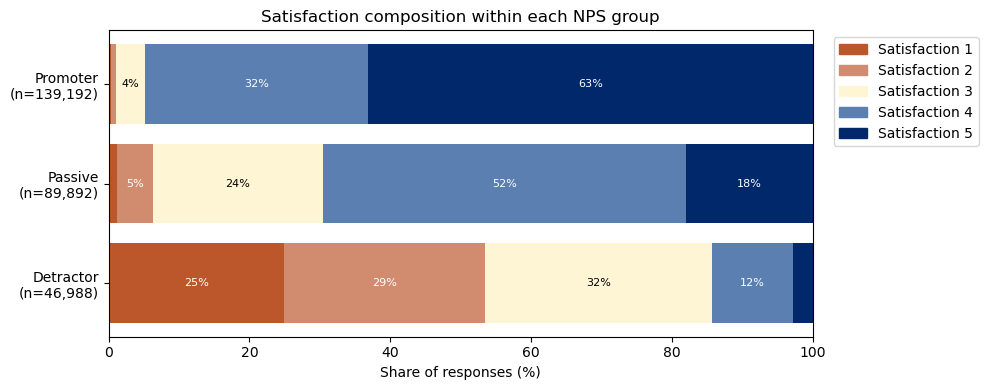

In [9]:
# Satisfaction composition within each NPS group
nps_col = "question_qid61_nps_group"
sat_col = "question_overall_rating"

d = raw_responses[[nps_col, sat_col]].copy()
d[sat_col] = pd.to_numeric(d[sat_col], errors="coerce")
d = d.dropna(subset=[nps_col, sat_col])
d = d[d[sat_col].between(1, 5)]

nps_order = ["Detractor", "Passive", "Promoter"]
sat_colors = {
    1: "#bc572c", 2: "#d18b6f", 3: "#fdf5d4", 4: "#5a7fb0", 5: "#00286a",
}

fig, ax = plt.subplots(figsize=(10, 4))
for i, grp in enumerate(nps_order):
    s = d.loc[d[nps_col] == grp, sat_col].astype(int)
    n = len(s)
    left = 0
    for score, color in sat_colors.items():
        width = (s == score).sum() / n * 100
        ax.barh(i, width, left=left, color=color)
        if width > 4:
            txt_color = "black" if score == 3 else "white"
            ax.text(left + width / 2, i, f"{width:.0f}%",
                    ha="center", va="center", color=txt_color, fontsize=8)

        left += width

ax.set_yticks(range(len(nps_order)))
ax.set_yticklabels([f"{g}\n(n={ (d[nps_col]==g).sum():,})" for g in nps_order])
ax.set_xlim(0, 100)
ax.set_xlabel("Share of responses (%)")
ax.set_title("Satisfaction composition within each NPS group")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in sat_colors.values()]
ax.legend(handles, [f"Satisfaction {k}" for k in sat_colors], bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()


## NPS

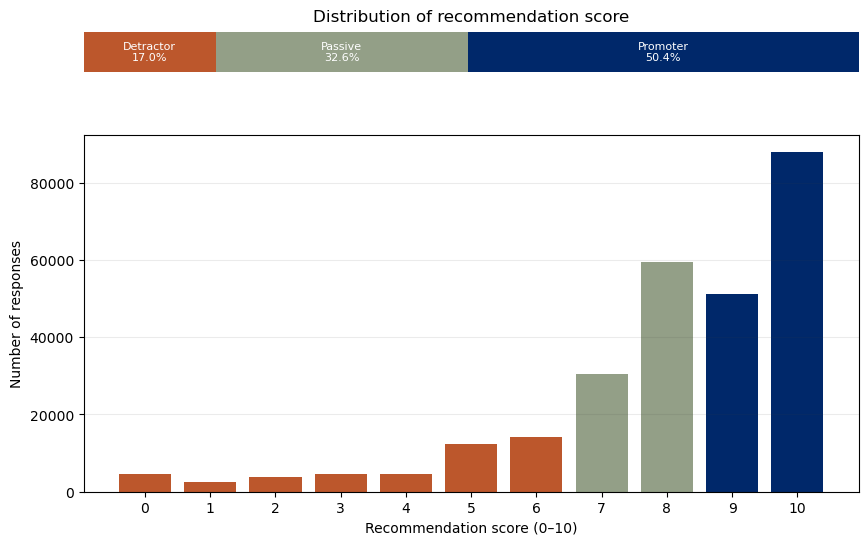

In [10]:
score_col = "metadata_recommendation_nps_a"
counts = raw_responses[score_col].value_counts().sort_index()

# NPS bands: 0-6 detractor, 7-8 passive, 9-10 promoter
bands = {"Detractor": "#bc572c", "Passive": "#939f87", "Promoter": "#00286a"}

score_band = {}
colors = []
for s in counts.index:
    si = int(s)
    if si <= 6:
        name = "Detractor"
    elif si <= 8:
        name = "Passive"
    else:
        name = "Promoter"
    score_band[s] = name
    colors.append(bands[name])

# band totals + proportions
band_totals = {name: 0 for name in bands}
for s, c in counts.items():
    band_totals[score_band[s]] += c
total = sum(band_totals.values())
band_props = {name: band_totals[name] / total * 100 for name in bands}

fig, (ax_top, ax) = plt.subplots(
    2, 1, figsize=(10, 6), height_ratios=[1, 8], gridspec_kw={"hspace": 0.3}
)

# 100% stacked proportion bar
left = 0
for name, color in bands.items():
    width = band_props[name]
    ax_top.barh(0, width, left=left, color=color)
    if width > 3:
        ax_top.text(left + width / 2, 0, f"{name}\n{width:.1f}%",
                    ha="center", va="center", color="white", fontsize=8)
    left += width
ax_top.set_xlim(0, 100)
ax_top.axis("off")
ax_top.set_title("Distribution of recommendation score")

# recommendation score distribution
ax.bar(counts.index, counts.values, color=colors)
ax.set_xlabel("Recommendation score (0–10)")
ax.set_ylabel("Number of responses")
ax.set_xticks(counts.index)
ax.grid(True, axis="y", alpha=0.1, color="#404040")

In [11]:
raw_promoter_count = len(raw_responses[raw_responses['question_qid61_nps_group'] == 'Promoter'])
raw_detractor_count = len(raw_responses[raw_responses['question_qid61_nps_group'] == 'Detractor'])
raw_overall_nps = (raw_promoter_count - raw_detractor_count) / len(raw_responses) * 100
print(f"Overall current NPS from raw survey responses (from May 2024): {raw_overall_nps:.2f}")


promoter_count = len(main_block[main_block['question_qid61_nps_group'] == 'Promoter'])
detractor_count = len(main_block[main_block['question_qid61_nps_group'] == 'Detractor'])
overall_nps = (promoter_count - detractor_count) / len(main_block) * 100
print(f"Overall current NPS from filtered survey responses (from January 2025): {overall_nps:.2f}")

Overall current NPS from raw survey responses (from May 2024): 33.40
Overall current NPS from filtered survey responses (from January 2025): 31.26


In [12]:
# Monthly NPS from raw_responses
raw_responses["month"] = pd.to_datetime(raw_responses["metadata_departure_date"]).dt.tz_localize(None).dt.to_period("M")

monthly_nps = (
    raw_responses.groupby("month")["question_qid61_nps_group"]
    .agg(
        n="count",
        promoters=lambda s: (s == "Promoter").sum(),
        detractors=lambda s: (s == "Detractor").sum(),
    )
)
monthly_nps["nps"] = (monthly_nps["promoters"] - monthly_nps["detractors"]) / monthly_nps["n"] * 100

In [13]:
monthly_nps.head()

,n,promoters,detractors,nps
month,,,,
2024-04,438,273,64,48
2024-05,6948,4257,768,50
2024-06,7236,3639,1259,33
2024-07,8031,3715,1555,27
2024-08,15314,7633,2687,32


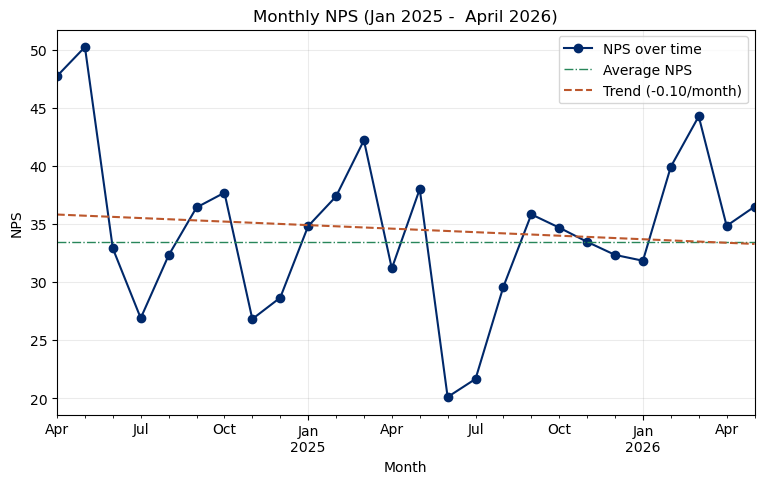

In [20]:
# Keep only months from the start of 2025
monthly_nps_2025 = monthly_nps[monthly_nps.index >= "2025-01"]
monthly_nps_2025 = monthly_nps[monthly_nps.index <= "2026-05"]

# Plot monthly NPS over time
ax = monthly_nps_2025["nps"].plot(marker="o", figsize=(9, 5), color='#00286a', label='NPS over time')
ax.set_title("Monthly NPS (Jan 2025 -  April 2026)")
ax.set_xlabel("Month")
ax.set_ylabel("NPS")
ax.axhline(raw_overall_nps, color="#28865A", linewidth=1, linestyle="dashdot", label='Average NPS')

# Trend line (linear fit over months)
x = np.arange(len(monthly_nps_2025))
coeffs = np.polyfit(x, monthly_nps_2025["nps"].values, 1)
trend = np.poly1d(coeffs)(x)
ax.plot(monthly_nps_2025.index, trend, linestyle="--", color="#bc572c",
        label=f'Trend ({coeffs[0]:+.2f}/month)')

# ax.set_facecolor('#fdf5d4')
ax.legend()
ax.grid(True, color='#404040', alpha=0.1)


Text(0.5, 1.02, 'Distribution of recommendation score by route')

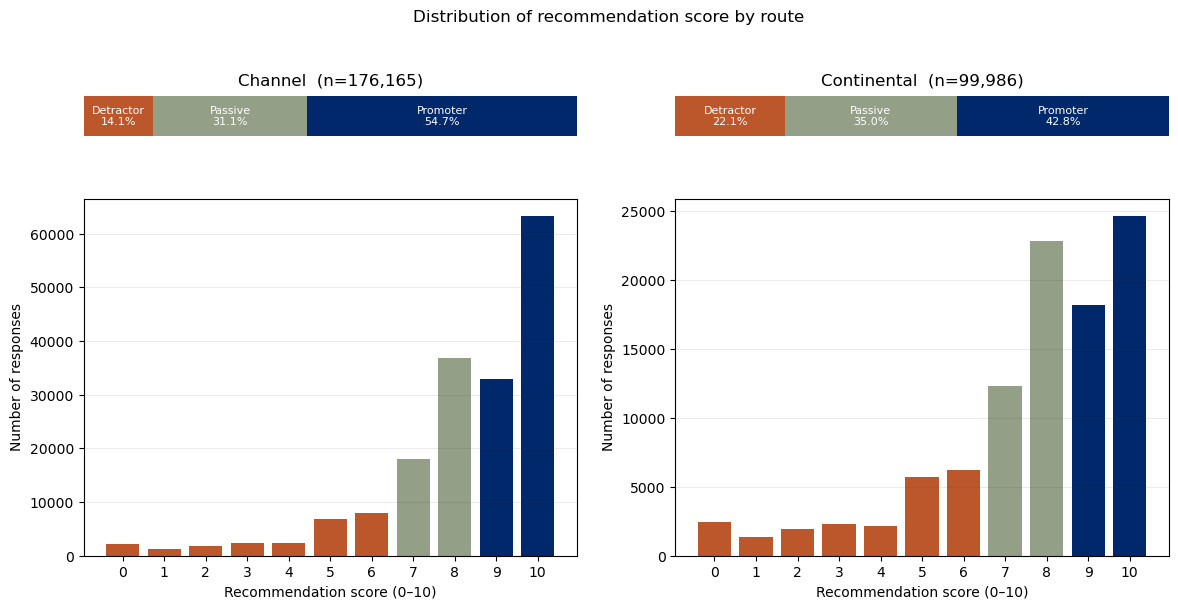

In [14]:
routes = {"Blue": "Channel", "Red": "Continental"}

fig, axes = plt.subplots(
    2, len(routes), figsize=(7 * len(routes), 6),
    height_ratios=[1, 8], gridspec_kw={"hspace": 0.3, "wspace": 0.2},
)

for col, (route_code, route_name) in enumerate(routes.items()):
    ax_top = axes[0, col]
    ax = axes[1, col]

    sub = raw_responses[raw_responses["metadata_route"] == route_code]
    counts = sub[score_col].value_counts().sort_index()

    # assign each score to a band
    score_band = {}
    colors = []
    for s in counts.index:
        si = int(s)
        if si <= 6:
            name = "Detractor"
        elif si <= 8:
            name = "Passive"
        else:
            name = "Promoter"
        score_band[s] = name
        colors.append(bands[name])

    # band totals + proportions
    band_totals = {name: 0 for name in bands}
    for s, c in counts.items():
        band_totals[score_band[s]] += c
    total = sum(band_totals.values())
    band_props = {name: band_totals[name] / total * 100 for name in bands}

    # 100% stacked proportion bar
    left = 0
    for name, color in bands.items():
        width = band_props[name]
        ax_top.barh(0, width, left=left, color=color)
        if width > 3:
            ax_top.text(left + width / 2, 0, f"{name}\n{width:.1f}%",
                        ha="center", va="center", color="white", fontsize=8)
        left += width
    ax_top.set_xlim(0, 100)
    ax_top.axis("off")
    ax_top.set_title(f"{route_name}  (n={total:,})")

    # recommendation score distribution
    ax.bar(counts.index, counts.values, color=colors)
    ax.set_xlabel("Recommendation score (0–10)")
    ax.set_ylabel("Number of responses")
    ax.set_xticks(counts.index)
    ax.grid(True, axis="y", alpha=0.1, color="#404040")

fig.suptitle("Distribution of recommendation score by route", y=1.02)

In [15]:
raw_responses.dropna(subset=['metadata_departure_date'], inplace=True)

channel = raw_responses[raw_responses['metadata_route'] == 'Blue']
continental = raw_responses[raw_responses['metadata_route'] == 'Red']

# Channel NPS
channel_promoter = len(channel[channel['question_qid61_nps_group'] == 'Promoter'])
channel_detractor = len(channel[channel['question_qid61_nps_group'] == 'Detractor'])
channel_nps = (channel_promoter - channel_detractor) / len(channel) * 100
print(f"Channel NPS (May 2024 onwards): {channel_nps:.2f}")

# Continental NPS
continental_promoter = len(continental[continental['question_qid61_nps_group'] == 'Promoter'])
continental_detractor = len(continental[continental['question_qid61_nps_group'] == 'Detractor'])
continental_nps = (continental_promoter - continental_detractor) / len(continental) * 100
print(f"Continental NPS (May 2024 onwards): {continental_nps:.2f}")

Channel NPS (May 2024 onwards): 40.59
Continental NPS (May 2024 onwards): 20.74


In [16]:
channel["month"] = pd.to_datetime(channel["metadata_departure_date"]).dt.tz_localize(None).dt.to_period("M")
continental["month"] = pd.to_datetime(continental["metadata_departure_date"]).dt.tz_localize(None).dt.to_period("M")

# Channel monthly NPS
channel_monthly = (
    channel.groupby("month")["question_qid61_nps_group"]
    .agg(
        n="count",
        promoters=lambda s: (s == "Promoter").sum(),
        detractors=lambda s: (s == "Detractor").sum(),
    )
)
channel_monthly["nps"] = (channel_monthly["promoters"] - channel_monthly["detractors"]) / channel_monthly["n"] * 100

# Continental monthly NPS
continental_monthly = (
    continental.groupby("month")["question_qid61_nps_group"]
    .agg(
        n="count",
        promoters=lambda s: (s == "Promoter").sum(),
        detractors=lambda s: (s == "Detractor").sum(),
    )
)
continental_monthly["nps"] = (continental_monthly["promoters"] - continental_monthly["detractors"]) / continental_monthly["n"] * 100

C:\Users\Vincent\AppData\Local\Temp\ipykernel_27092\678182960.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  channel["month"] = pd.to_datetime(channel["metadata_departure_date"]).dt.tz_localize(None).dt.to_period("M")
C:\Users\Vincent\AppData\Local\Temp\ipykernel_27092\678182960.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  continental["month"] = pd.to_datetime(continental["metadata_departure_date"]).dt.tz_localize(None).dt.to_period("M")


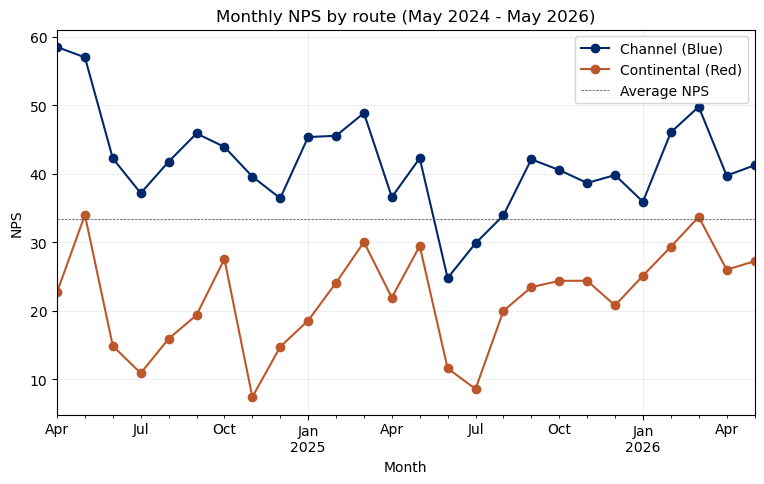

In [17]:
# Plot monthly NPS by route
ax = channel_monthly["nps"].plot(marker="o", figsize=(9, 5), label="Channel (Blue)", color='#00286a')
continental_monthly["nps"].plot(marker="o", ax=ax, label="Continental (Red)", color='#bc572c')
ax.set_title("Monthly NPS by route (May 2024 - May 2026)")
ax.set_xlabel("Month")
ax.set_ylabel("NPS")
ax.axhline(raw_overall_nps, color="#404040", linewidth=0.5, linestyle="--", label='Average NPS')
ax.legend()
# ax.set_facecolor('#fdf5d4')
ax.grid(True, alpha=0.2)

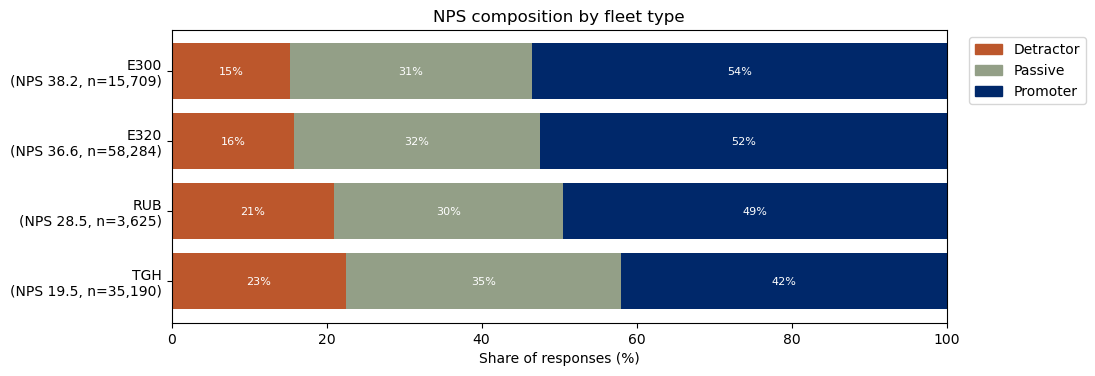

In [18]:
# Promoter/Passive/Detractor proportions by fleet type
nps_bands = {"Detractor": "#bc572c", "Passive": "#939f87", "Promoter": "#00286a"}

# order fleets by NPS (reuse fleet_nps if available, else compute order)
fleet_order = (
    main_block.groupby("equipment_type")["question_qid61_nps_group"]
    .agg(lambda s: ((s == "Promoter").sum() - (s == "Detractor").sum()) / len(s) * 100)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 0.7 * len(fleet_order) + 1))
ylabels = []
for i, fleet in enumerate(fleet_order.index):
    g = main_block.loc[main_block["equipment_type"] == fleet, "question_qid61_nps_group"]
    n = len(g)
    props = {
        "Detractor": (g == "Detractor").sum() / n * 100,
        "Passive":   (g == "Passive").sum() / n * 100,
        "Promoter":  (g == "Promoter").sum() / n * 100,
    }
    left = 0
    for name, color in nps_bands.items():
        width = props[name]
        ax.barh(i, width, left=left, color=color)
        if width > 4:
            ax.text(left + width / 2, i, f"{width:.0f}%",
                    ha="center", va="center", color="white", fontsize=8)
        left += width
    ylabels.append(f"{fleet}\n(NPS {fleet_order[fleet]:.1f}, n={n:,})")

ax.set_yticks(range(len(fleet_order)))
ax.set_yticklabels(ylabels)
ax.set_xlim(0, 100)
ax.set_xlabel("Share of responses (%)")
ax.set_title("NPS composition by fleet type")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in nps_bands.values()]
ax.legend(handles, nps_bands.keys(), bbox_to_anchor=(1.02, 1), loc="upper left")


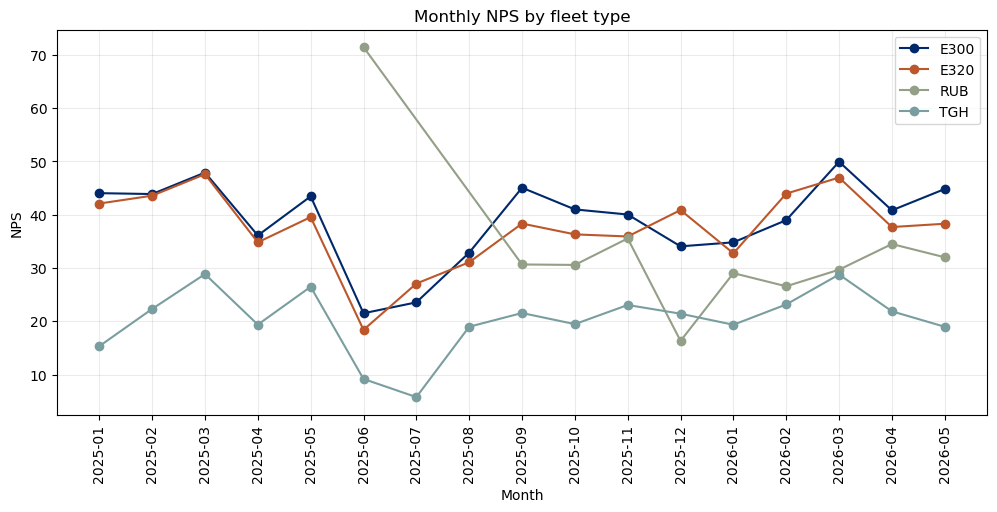

In [19]:
# Monthly NPS by fleet type
mb = main_block[["equipment_type", "question_qid61_nps_group", "origin_theoretical_time"]].copy()
mb["month"] = pd.to_datetime(mb["origin_theoretical_time"]).dt.tz_localize(None).dt.to_period("M")

fleet_monthly = (
    mb.groupby(["equipment_type", "month"])["question_qid61_nps_group"]
    .agg(
        n="count",
        promoters=lambda s: (s == "Promoter").sum(),
        detractors=lambda s: (s == "Detractor").sum(),
    )
)
fleet_monthly["nps"] = (fleet_monthly["promoters"] - fleet_monthly["detractors"]) / fleet_monthly["n"] * 100

palette = ["#00286a", "#bc572c", "#939f87", "#7a9e9f", "#c9a227", "#5c5c5c"]

fig, ax = plt.subplots(figsize=(12, 5))
for color, fleet in zip(palette, fleet_monthly.index.get_level_values(0).unique()):
    s = fleet_monthly.loc[fleet, "nps"]
    s.index = s.index.astype(str)
    ax.plot(s.index, s.values, marker="o", label=fleet, color=color)

ax.set_title("Monthly NPS by fleet type")
ax.set_xlabel("Month")
ax.set_ylabel("NPS")
ax.tick_params(axis="x", rotation=90)
ax.legend()
ax.grid(True, color="#404040", alpha=0.1)


                    n  promoters  detractors  nps
equipment_type                                   
TGH             35190      14806        7930   20
RUB              3625       1793         759   29
E320            58284      30575        9217   37
E300            15709       8410        2409   38


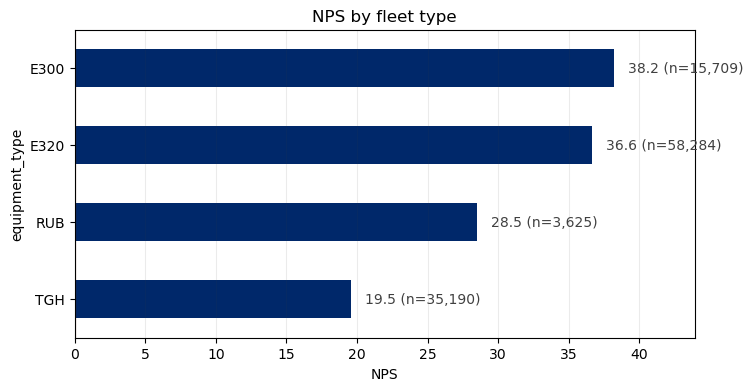

In [20]:
# NPS by fleet type (equipment_type)
fleet_nps = (
    main_block.groupby("equipment_type")["question_qid61_nps_group"]
    .agg(
        n="count",
        promoters=lambda s: (s == "Promoter").sum(),
        detractors=lambda s: (s == "Detractor").sum(),
    )
)
fleet_nps["nps"] = (fleet_nps["promoters"] - fleet_nps["detractors"]) / fleet_nps["n"] * 100
fleet_nps = fleet_nps.sort_values("nps")
print(fleet_nps)

# Plot
ax = fleet_nps["nps"].plot.barh(figsize=(8, 4), color="#00286a")
ax.set_title("NPS by fleet type")
ax.set_xlabel("NPS")
ax.axvline(0, color="#bc572c", linewidth=0.8)

for i, (name, row) in enumerate(fleet_nps.iterrows()):
    val = row["nps"]
    ax.text(
        val + (1 if val >= 0 else -1), i,
        f"{val:.1f} (n={int(row['n']):,})",
        va="center",
        ha="left" if val >= 0 else "right",
        color="#404040",
    )
ax.margins(x=0.15)
ax.grid(True, axis="x", alpha=0.1, color="#404040")

In [21]:
non_business_purposes = ['Leisure', 'Visiting friends or relatives']

non_business = raw_responses[raw_responses['question_main_trip_purpose'].isin(non_business_purposes)]
business = raw_responses[raw_responses['question_main_trip_purpose'] == 'Business']
regulars = raw_responses[raw_responses['question_main_trip_purpose'] == 'Regular commute']

Non-business (Leisure/VFR)   38
Business                     13
Regular commute              -4
dtype: float64


(array([0, 1, 2]),
 [Text(0, 0, 'Regular commute'),
  Text(1, 0, 'Business'),
  Text(2, 0, 'Non-business (Leisure/VFR)')])

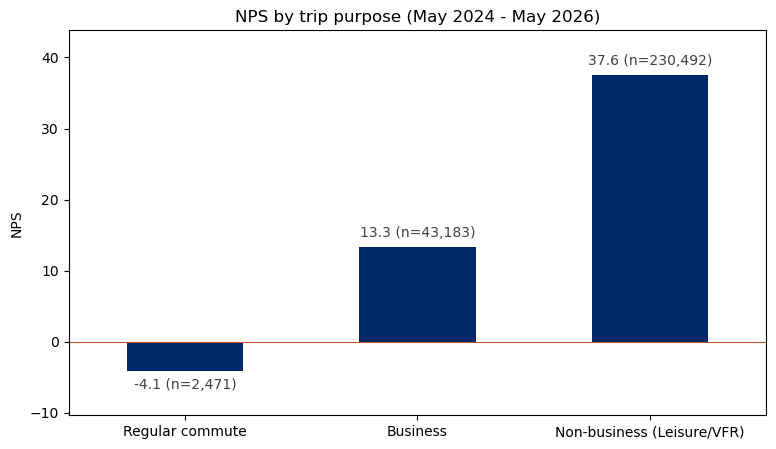

In [22]:
groups = {
    "Non-business (Leisure/VFR)": non_business,
    "Business": business,
    "Regular commute": regulars,
}

nps_values = {}
counts = {}
for name, df in groups.items():
    g = df["question_qid61_nps_group"]
    promoters = (g == "Promoter").sum()
    detractors = (g == "Detractor").sum()
    nps_values[name] = (promoters - detractors) / len(df) * 100
    counts[name] = len(df)

nps_by_purpose = pd.Series(nps_values)
counts = pd.Series(counts)
print(nps_by_purpose)

# Plot
ordered_nps = nps_by_purpose.sort_values()
ax = ordered_nps.plot.bar(figsize=(9, 5), color="#00286a")
ax.set_title("NPS by trip purpose (May 2024 - May 2026)")
ax.set_ylabel("NPS")
ax.axhline(0, color="#bc572c", linewidth=0.8)

gap = 1
for i, (name, val) in enumerate(ordered_nps.items()):
    va = "bottom" if val >= 0 else "top"
    y = val + gap if val >= 0 else val - gap
    ax.text(
        i, y,
        f"{val:.1f} (n={counts[name]:,})",
        ha="center",
        va=va,
        color='#404040'
    )
ax.margins(y=0.15)
plt.xticks(rotation=0)


## Satisfaction

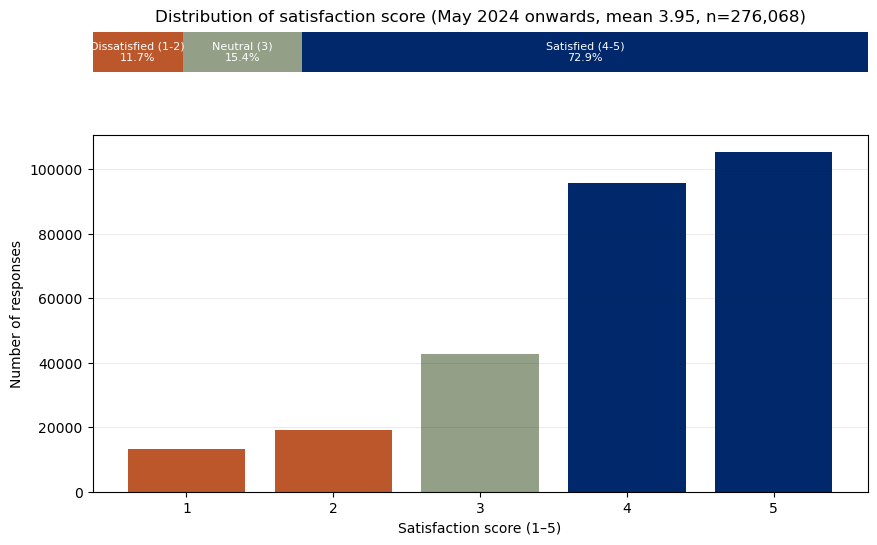

In [23]:
sat_col = "question_overall_rating"
sat_bands = {"Dissatisfied (1-2)": "#bc572c", "Neutral (3)": "#939f87", "Satisfied (4-5)": "#00286a"}

s = pd.to_numeric(raw_responses[sat_col], errors="coerce").dropna()
counts = s.value_counts().sort_index()
colors = [
    sat_bands["Dissatisfied (1-2)"] if sc <= 2 else
    sat_bands["Neutral (3)"] if sc == 3 else
    sat_bands["Satisfied (4-5)"]
    for sc in counts.index
]
total = len(s)
band_props = {
    "Dissatisfied (1-2)": s.isin([1, 2]).sum() / total * 100,
    "Neutral (3)":        (s == 3).sum() / total * 100,
    "Satisfied (4-5)":    s.isin([4, 5]).sum() / total * 100,
}

fig, (ax_top, ax) = plt.subplots(2, 1, figsize=(10, 6),
                                 height_ratios=[1, 8], gridspec_kw={"hspace": 0.3})
left = 0
for name, color in sat_bands.items():
    w = band_props[name]
    ax_top.barh(0, w, left=left, color=color)
    if w > 4:
        ax_top.text(left + w / 2, 0, f"{name}\n{w:.1f}%",
                    ha="center", va="center", color="white", fontsize=8)
    left += w
ax_top.set_xlim(0, 100)
ax_top.axis("off")
ax_top.set_title(f"Distribution of satisfaction score (May 2024 onwards, mean {s.mean():.2f}, n={total:,})")

ax.bar(counts.index, counts.values, color=colors)
ax.set_xlabel("Satisfaction score (1–5)")
ax.set_ylabel("Number of responses")
ax.set_xticks(counts.index)
ax.grid(True, axis="y", alpha=0.1, color="#404040")


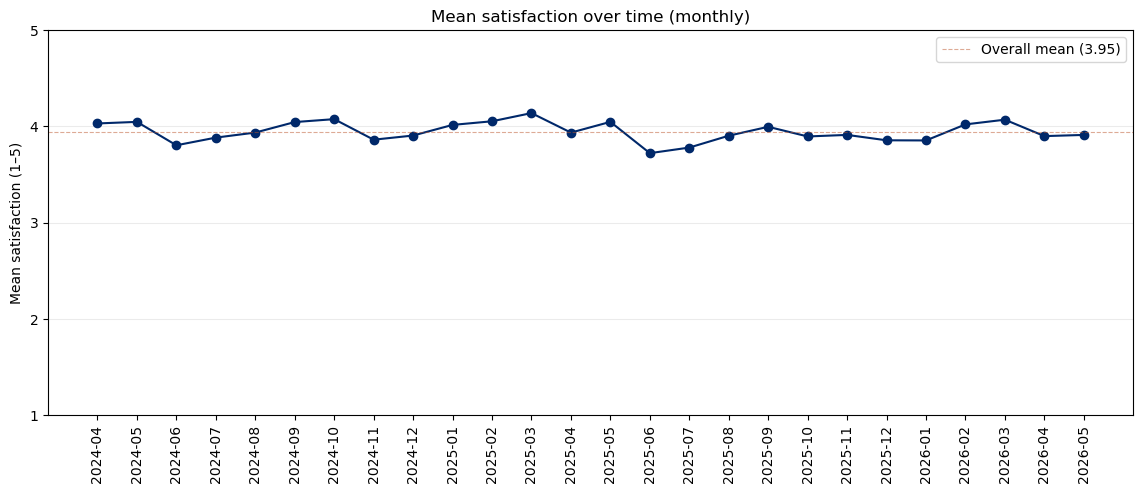

In [24]:
sat = raw_responses[[sat_col, "metadata_departure_date"]].copy()
sat[sat_col] = pd.to_numeric(sat[sat_col], errors="coerce")
sat = sat.dropna(subset=[sat_col])
sat["month"] = pd.to_datetime(sat["metadata_departure_date"]).dt.tz_localize(None).dt.to_period("M")

monthly_mean = sat.groupby("month")[sat_col].mean()
monthly_mean.index = monthly_mean.index.astype(str)

overall_mean = sat[sat_col].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_mean.index, monthly_mean.values, color="#00286a", marker="o", linewidth=1.5)
ax.axhline(overall_mean, color="#bc572c", linestyle="--", linewidth=0.8,
           label=f"Overall mean ({overall_mean:.2f})", alpha=0.5)
ax.set_ylim(1, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_ylabel("Mean satisfaction (1–5)")
ax.set_title("Mean satisfaction over time (monthly)")
ax.tick_params(axis="x", rotation=90)
ax.grid(True, axis="y", alpha=0.1, color="#404040")
ax.legend()


Text(0.5, 1.02, 'Distribution of satisfaction score by route')

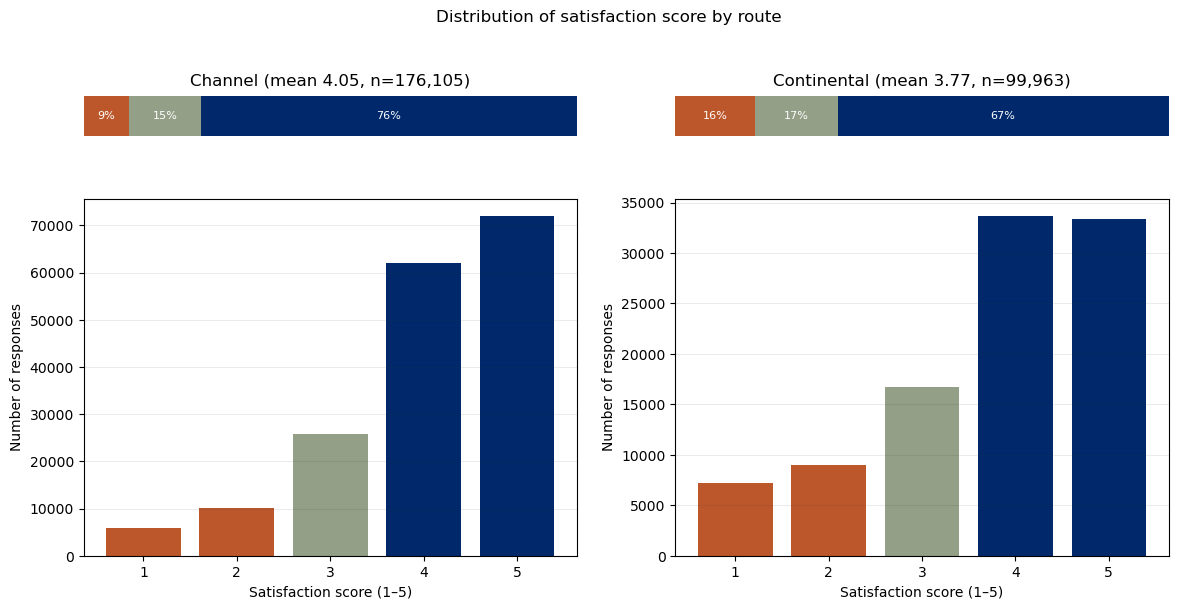

In [25]:
fig, axes = plt.subplots(
    2, len(routes), figsize=(7 * len(routes), 6),
    height_ratios=[1, 8], gridspec_kw={"hspace": 0.3, "wspace": 0.2},
)

for col, (route_code, route_name) in enumerate(routes.items()):
    ax_top = axes[0, col]
    ax = axes[1, col]

    s = pd.to_numeric(
        raw_responses.loc[raw_responses["metadata_route"] == route_code, sat_col],
        errors="coerce",
    ).dropna()
    counts = s.value_counts().sort_index()

    # assign each score to a band
    colors = []
    for score in counts.index:
        if score <= 2:
            colors.append(sat_bands["Dissatisfied (1-2)"])
        elif score == 3:
            colors.append(sat_bands["Neutral (3)"])
        else:
            colors.append(sat_bands["Satisfied (4-5)"])

    # band proportions
    total = len(s)
    band_props = {
        "Dissatisfied (1-2)": s.isin([1, 2]).sum() / total * 100,
        "Neutral (3)":        (s == 3).sum() / total * 100,
        "Satisfied (4-5)":    s.isin([4, 5]).sum() / total * 100,
    }

    # 100% stacked proportion bar
    left = 0
    for name, color in sat_bands.items():
        width = band_props[name]
        ax_top.barh(0, width, left=left, color=color)
        if width > 4:
            ax_top.text(left + width / 2, 0, f"{width:.0f}%",
                        ha="center", va="center", color="white", fontsize=8)
        left += width
    ax_top.set_xlim(0, 100)
    ax_top.axis("off")
    ax_top.set_title(f"{route_name} (mean {s.mean():.2f}, n={total:,})")

    # per-score distribution
    ax.bar(counts.index, counts.values, color=colors)
    ax.set_xlabel("Satisfaction score (1–5)")
    ax.set_ylabel("Number of responses")
    ax.set_xticks(counts.index)
    ax.grid(True, axis="y", alpha=0.1, color="#404040")

fig.suptitle("Distribution of satisfaction score by route", y=1.02)


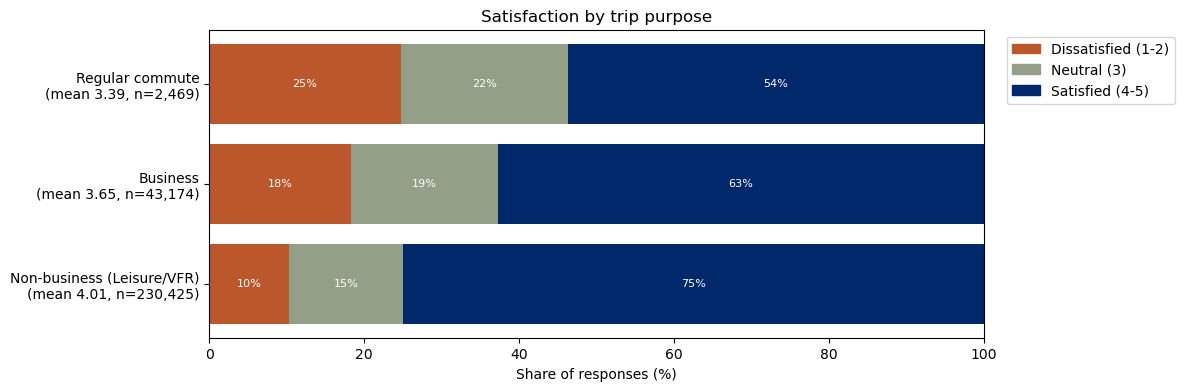

In [26]:
fig, ax = plt.subplots(figsize=(10, 4))
ylabels = []
for i, (gname, gdf) in enumerate(groups.items()):
    s = pd.to_numeric(gdf[sat_col], errors="coerce").dropna()
    props = {
        "Dissatisfied (1-2)": s.isin([1, 2]).sum() / len(s) * 100,
        "Neutral (3)":        (s == 3).sum() / len(s) * 100,
        "Satisfied (4-5)":    s.isin([4, 5]).sum() / len(s) * 100,
    }
    left = 0
    for name, color in sat_bands.items():
        width = props[name]
        ax.barh(i, width, left=left, color=color)
        if width > 4:
            ax.text(left + width / 2, i, f"{width:.0f}%",
                    ha="center", va="center", color="white", fontsize=8)
        left += width
    ylabels.append(f"{gname}\n(mean {s.mean():.2f}, n={len(s):,})")

ax.set_yticks(range(len(groups)))
ax.set_yticklabels(ylabels)
ax.set_xlim(0, 100)
ax.set_xlabel("Share of responses (%)")
ax.set_title("Satisfaction by trip purpose")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in sat_bands.values()]
ax.legend(handles, sat_bands.keys(), bbox_to_anchor=(1.02, 1), loc="upper left")

# Correlations analysis

## Toilet cleanliness - LDA operations

In [24]:
onboard_ind = pd.read_parquet("../data/analysis/individual/on_board_individual.parquet")
onboard_agg = pd.read_parquet("../data/analysis/aggregated/on_board_aggregated.parquet")
fleet_availability = pd.read_csv("../data/operational/Fleet Availability.csv")
system_analysis = pd.read_parquet("../data/features_interactions_analysis.parquet")

In [25]:
onboard_ind.head()

,question_on_board_the_train1_the_temperature_on_board,question_on_board_the_train1_the_availability_of_toilet_facilities_on_board,question_on_board_the_train1_the_noise_on_board,question_on_board_the_train2_the_information_and_announcements_provided_on_board,question_on_board_the_train2_the_cleanliness_of_toilet_facilities_on_board_the_train,service_id,trainset,equipment_type,train_service,route_type,origin_theoretical_time,destination_theoretical_time,restriction_open_Toilets,restriction_open_Air Conditioning,restriction_open_Refrigeration,restriction_open_Windows,restriction_open_WiFi,restriction_open_Heating,total restrictions,restriction_days_Toilets,restriction_days_Air Conditioning,restriction_days_Refrigeration,restriction_days_Windows,restriction_days_WiFi,restriction_days_Heating,longest restriction,pm_days_since_catering,pm_days_since_toilet,pm_days_since_climate,pm_days_since_interior,pm_days_since_reliability,pm_days_since_comms,pm_days_since_wifi,average days since last exams,pm_has_prior_catering,pm_has_prior_toilet,pm_has_prior_climate,pm_has_prior_interior,pm_has_prior_reliability,pm_has_prior_comms,pm_has_prior_wifi,cm_open_climate,cm_open_wifi,cm_open_interior,cm_open_catering,cm_open_toilet,cm_open_cleaning,total open faults,clean_score_routine,clean_hours_since_routine,clean_score_deep,clean_days_since_deep,last_clean_score,hours_since_last_clean,clean_has_prior_routine,clean_has_prior_deep,lda_hours_since,n_trainsets,Exceeded Rotation Time,early_journey_delay_minute,arrival_delay_minute,compensation_liability_evouchers,compensation_liability_cash
112251,<NA>,<NA>,<NA>,<NA>,<NA>,9937_20250101,4540,TGH,9937,Continental,2025-01-01 11:43:00+00:00,2025-01-01 15:20:00+00:00,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28,NaN,10,19,0,0,0,0,1,0,1,11,0,38,8,17,3,77,NaN,NaN,NaN,NaN,NaN,NaN,0,0,12,1,00:00:00,0,8,0.00,0.00
112252,<NA>,<NA>,<NA>,<NA>,<NA>,9937_20250101,4540,TGH,9937,Continental,2025-01-01 11:43:00+00:00,2025-01-01 15:20:00+00:00,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28,NaN,10,19,0,0,0,0,1,0,1,11,0,38,8,17,3,77,NaN,NaN,NaN,NaN,NaN,NaN,0,0,12,1,00:00:00,0,8,0.00,0.00
112253,5,4,5,5,3,9937_20250101,4540,TGH,9937,Continental,2025-01-01 11:43:00+00:00,2025-01-01 15:20:00+00:00,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28,NaN,10,19,0,0,0,0,1,0,1,11,0,38,8,17,3,77,NaN,NaN,NaN,NaN,NaN,NaN,0,0,12,1,00:00:00,0,8,0.00,0.00
81305,<NA>,<NA>,<NA>,<NA>,<NA>,9351_20250101,4538,TGH,9351,Continental,2025-01-01 14:22:00+00:00,2025-01-01 17:50:00+00:00,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27,NaN,127,77,0,0,0,0,1,0,1,4,0,22,9,11,4,50,NaN,NaN,NaN,NaN,NaN,NaN,0,0,14,1,00:00:00,20,37,0.00,0.00
81306,<NA>,<NA>,<NA>,<NA>,<NA>,9351_20250101,4538,TGH,9351,Continental,2025-01-01 14:22:00+00:00,2025-01-01 17:50:00+00:00,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27,NaN,127,77,0,0,0,0,1,0,1,4,0,22,9,11,4,50,NaN,NaN,NaN,NaN,NaN,NaN,0,0,14,1,00:00:00,20,37,0.00,0.00


In [26]:
toilet_ind = onboard_ind[['question_on_board_the_train2_the_cleanliness_of_toilet_facilities_on_board_the_train', 'lda_hours_since', 'equipment_type']]
toilet_agg = onboard_agg[['question_on_board_the_train2_the_cleanliness_of_toilet_facilities_on_board_the_train', 'lda_hours_since', 'equipment_type']]
rename_dict = {'question_on_board_the_train2_the_cleanliness_of_toilet_facilities_on_board_the_train': 'toilet_cleanliness', 'lda_hours_since': 'hours_since_lda'}

toilet_ind.rename(columns = rename_dict, inplace=True)
toilet_agg.rename(columns=rename_dict, inplace=True)

C:\Users\Vincent\AppData\Local\Temp\ipykernel_27616\2024301334.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  toilet_ind.rename(columns = rename_dict, inplace=True)
C:\Users\Vincent\AppData\Local\Temp\ipykernel_27616\2024301334.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  toilet_agg.rename(columns=rename_dict, inplace=True)


In [27]:
toilet_ind.dropna(inplace=True)
toilet_agg.dropna(inplace=True)
print(len(toilet_ind))
print(len(toilet_agg))

19925
13550


C:\Users\Vincent\AppData\Local\Temp\ipykernel_27616\2856393309.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  toilet_ind.dropna(inplace=True)
C:\Users\Vincent\AppData\Local\Temp\ipykernel_27616\2856393309.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  toilet_agg.dropna(inplace=True)


n = 13,550
Pearson  r = 0.054  (p = 2.33e-10)
Spearman r = 0.044  (p = 3.28e-07)


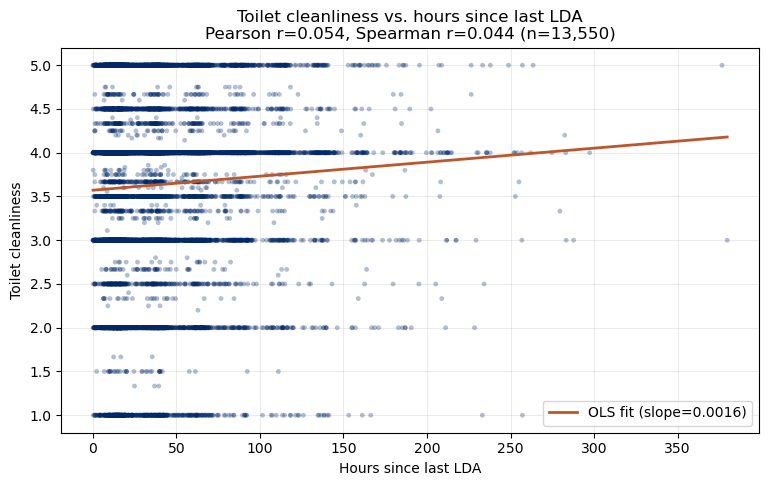

In [28]:
from scipy import stats

# Correlation: toilet cleanliness vs. hours since last LDA (deep clean)
corr_df = toilet_agg[["toilet_cleanliness", "hours_since_lda"]].apply(
    pd.to_numeric, errors="coerce"
).dropna()

x = corr_df["hours_since_lda"]
y = corr_df["toilet_cleanliness"]

pearson_r, pearson_p = stats.pearsonr(x, y)
spearman_r, spearman_p = stats.spearmanr(x, y)

print(f"n = {len(corr_df):,}")
print(f"Pearson  r = {pearson_r:.3f}  (p = {pearson_p:.3g})")
print(f"Spearman r = {spearman_r:.3f}  (p = {spearman_p:.3g})")

# Scatter + regression line
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x, y, s=12, alpha=0.3, color="#00286a", edgecolor="none")

# OLS fit line
slope, intercept = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, slope * xs + intercept, color="#bc572c", linewidth=2,
        label=f"OLS fit (slope={slope:.4f})")

ax.set_xlabel("Hours since last LDA")
ax.set_ylabel("Toilet cleanliness")
ax.set_title(f"Toilet cleanliness vs. hours since last LDA\nPearson r={pearson_r:.3f}, Spearman r={spearman_r:.3f} (n={len(corr_df):,})")
ax.legend()
ax.grid(True, alpha=0.1, color="#404040")


E300 — n = 1,819
Pearson  r = 0.013  (p = 0.566)
Spearman r = -0.002  (p = 0.934)


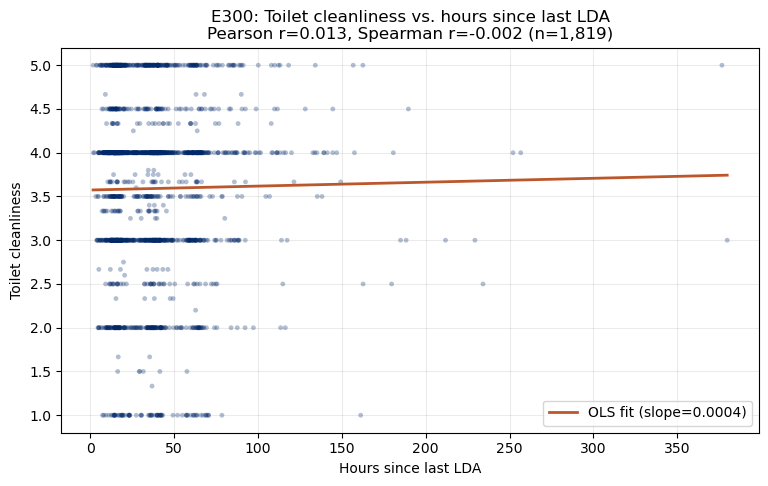

In [29]:
from scipy import stats

# Filter to E300 fleet only
toilet_e300 = toilet_agg[toilet_agg["equipment_type"] == "E300"].copy()

# Correlation: toilet cleanliness vs. hours since last LDA (E300 only)
corr_e300 = toilet_e300[["toilet_cleanliness", "hours_since_lda"]].apply(
    pd.to_numeric, errors="coerce"
).dropna()

x = corr_e300["hours_since_lda"]
y = corr_e300["toilet_cleanliness"]

pearson_r, pearson_p = stats.pearsonr(x, y)
spearman_r, spearman_p = stats.spearmanr(x, y)

print(f"E300 — n = {len(corr_e300):,}")
print(f"Pearson  r = {pearson_r:.3f}  (p = {pearson_p:.3g})")
print(f"Spearman r = {spearman_r:.3f}  (p = {spearman_p:.3g})")

# Scatter + regression line
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x, y, s=12, alpha=0.3, color="#00286a", edgecolor="none")

slope, intercept = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, slope * xs + intercept, color="#bc572c", linewidth=2,
        label=f"OLS fit (slope={slope:.4f})")

ax.set_xlabel("Hours since last LDA")
ax.set_ylabel("Toilet cleanliness")
ax.set_title(f"E300: Toilet cleanliness vs. hours since last LDA\nPearson r={pearson_r:.3f}, Spearman r={spearman_r:.3f} (n={len(corr_e300):,})")
ax.legend()
ax.grid(True, alpha=0.1, color="#404040")


## NPS

Features ranked by correlation strength (mean |Spearman r|):
                  feature  Recommendation_r  Satisfaction_r  mean_abs_r
      Arrival delay (min)            -0.240          -0.315       0.278
Early-journey delay (min)            -0.218          -0.272       0.245
        Total open faults            -0.109          -0.080       0.095
Avg days since last exams             0.097           0.063       0.080
       Total restrictions             0.022           0.013       0.018
      Longest restriction             0.006           0.022       0.014
   Hours since last clean            -0.011          -0.007       0.009
         Last clean score            -0.001           0.004       0.002


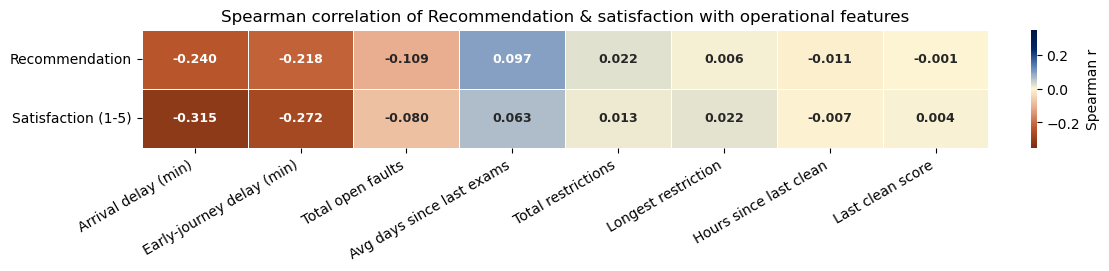

In [ ]:
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap

targets = {
    "Recommendation": "question_recommendation_score",  # numeric 0-10
    "Satisfaction (1-5)": "question_overall_rating",
}

features = [
    "total restrictions",
    "longest restriction",
    "average days since last exams",
    "total open faults",
    "last_clean_score",
    "hours_since_last_clean",
    "early_journey_delay_minute",
    "arrival_delay_minute",
]
label_map = {
    "total restrictions":            "Total restrictions",
    "longest restriction":           "Longest restriction",
    "average days since last exams": "Avg days since last exams",
    "total open faults":             "Total open faults",
    "last_clean_score":              "Last clean score",
    "hours_since_last_clean":        "Hours since last clean",
    "early_journey_delay_minute":    "Early-journey delay (min)",
    "arrival_delay_minute":          "Arrival delay (min)",
}

df = main_block[list(targets.values()) + features].apply(pd.to_numeric, errors="coerce")

rows = {}
for tname, tcol in targets.items():
    vals = {}
    for f in features:
        pair = df[[tcol, f]].dropna()
        if len(pair) < 3 or pair[tcol].nunique() < 2 or pair[f].nunique() < 2:
            vals[f] = np.nan
        else:
            vals[f] = stats.spearmanr(pair[tcol], pair[f])[0]
    rows[tname] = vals
spearman = pd.DataFrame(rows).T  # rows = targets, cols = features

strength = spearman.abs().mean(axis=0).sort_values(ascending=False)
spearman = spearman[strength.index]

ranked = pd.DataFrame({
    "feature":        [label_map[f] for f in strength.index],
    "Recommendation_r": spearman.loc["Recommendation"].values,
    "Satisfaction_r":   spearman.loc["Satisfaction (1-5)"].values,
    "mean_abs_r":       strength.values,
})
print("Features ranked by correlation strength (mean |Spearman r|):")
print(ranked.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

spearman_plot = spearman.rename(columns=label_map)

eurostar_div = LinearSegmentedColormap.from_list(
    "eurostar_bold",
    ["#7a2e12", "#bc572c", "#e8a98c", "#fdf5d4", "#6f8fc0", "#00286a", "#001540"],
)

vmax = float(np.nanmax(np.abs(spearman.values)))
vmax = np.ceil(vmax * 20) / 20

fig, ax = plt.subplots(figsize=(11, 2.6), constrained_layout=True)
sns.heatmap(
    spearman_plot, annot=True, fmt=".3f", cmap=eurostar_div, center=0,
    vmin=-vmax, vmax=vmax, linewidths=0.6, linecolor="#ffffff", ax=ax,
    cbar_kws={"label": "Spearman r"},
    annot_kws={"fontsize": 9, "fontweight": "bold"},
)
ax.set_title("Spearman correlation of Recommendation & satisfaction with operational features")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.tick_params(axis="x", labelrotation=30)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")

plt.show()